# Free money in a takeover? — the merger-arbitrage spread 🤝
### Buy the target below the offer, wait for the deal to close, pocket the difference — what's the catch?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Here's a trade that sounds like free money. A company gets a **takeover offer** — say **$95 a share, all cash**. The next day the target trades at **$82**. Just *buy it at $82, wait for the deal to close, and collect $95.* A clean **+16%**, and it has nothing to do with whether the broad market goes up or down. People call it a *market-neutral coupon.*

So what's the catch? The catch is the word **"wait."** Deals don't always close. When one **breaks** — blocked by regulators, financing falls through, the buyer walks — the target **craters** back to where it traded before the offer, a 20–40% loss in a single day. This notebook shows that the spread isn't a free lunch at all: it's the **premium you collect for selling insurance** against the deal falling through.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the skew? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** When a takeover closes, the target is **delisted** — its price history disappears from free data feeds. So our entry/exit prices are **documented public closes** carried in a real deal table (confirmed against live data for the two deals that *broke* and still trade). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from merger_arbitrage import data, strategy as st

# the real deal book is reproducible offline (documented closes in the table); the yfinance
# cache only confirms still-listed names, so HAVE_REAL is effectively always True here.
HAVE_REAL = True
F = data.load_real()
print("real deal book :", len(F), "deals |", int((~F["completed"]).sum()), "breaks",
      "| yfinance cache present:", data.have_real())

# frozen headline numbers (mirror of docs/results.md)
R = {'n': 20, 'n_closed': 16, 'n_breaks': 4, 'win': 80, 'entry_spread': 8.99, 'completed_spread': 7.09, 'break_mean': -19.39, 'mean': 1.79, 'median': 3.83, 'skew': -0.91, 't': 0.67, 'p_le0': 0.24, 'boot_lo': -2.65, 'boot_hi': 5.9, 'ann_mean': 5.66, 'ann_t': 2.09, 'costs': [(5, 1.79, 1.69, 0.63), (10, 1.79, 1.59, 0.59), (25, 1.79, 1.29, 0.48)], 'syn': [(0.0, 0.52, 1.1, 0.142, 14), (0.02, 2.41, 4.77, 0.0, 14), (0.05, 5.24, 9.56, 0.0, 14)]}


real deal book : 20 deals | 4 breaks | yfinance cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is there really a spread to collect? | **Yes.** Right after a deal is announced the target trades about **9% below** the cash offer, on average. |
| Do most deals close and pay it? | **Yes — about 80% do.** That's the seductive part: you win most of the time. |
| So is it free money? | **No.** In our book of 20 real deals, **4 broke** — and each break cost about **-19%**. Those four wipe out most of what the sixteen winners earn: the *average* deal returns just **+1.8%**. |
| Then why does it look so good? | **You're selling insurance.** Win small, often; lose big, rarely. A high win-rate with a rare disaster is what *writing insurance* looks like — not a free lunch. |

> The spread is real. "Free money" is not. You're being paid a premium to bet the deal won't break — and on an honest tape that premium roughly equals the losses when it does.

## 1 · The claim

> *"When a company agrees to be bought for cash, its stock should jump to the offer price — but it doesn't quite. It trades a few percent below, because the deal takes months to close and isn't 100% certain. Buy the target, hold to the close, and harvest that gap. It's steady, it's market-neutral, and it wins almost every time."*

This is **merger arbitrage** ("risk arb"), one of the oldest hedge-fund strategies. The logic is genuinely sound: the spread exists because closing takes time and carries risk. The seduction is the **win-rate** — most announced deals really do close. We'll rebuild the trade on real deals and look hard at the deals that *didn't*.

## 2 · So what?

If the spread were free money, it'd be one of the best risk-adjusted trades in markets: low correlation to stocks, a fat positive return, wins most of the time. Pensions and hedge funds would (and do) pile in. But there's a hidden cost the pitch glosses over: **what you give up when a deal breaks.** The right question isn't *"how often do I win?"* — it's *"when I add up the small frequent wins and the rare giant losses, is there anything left?"* A trade that wins 80% of the time can still have an **expected return of zero** if the 20% of losers are big enough. That's the whole game here.

## 3 · How would we even know?

We build a book of **20 real announced all-cash US deals** (2020–2024) — on purpose a mix of clean closes **and** famous breaks (JetBlue/Spirit, TD/First Horizon, Avangrid/PNM, MaxLinear/Silicon Motion).

1. **Enter after the news.** Buy the target at the close **one day after** the deal is announced (no cheating — you can't trade before it's public).
2. **Mark the outcome honestly.** If the deal closes, you collect the offer. If it **breaks**, the target snaps back to where it traded *before* the bid — that's your loss.
3. **Add it all up.** Average the realized return across *all* deals — winners and breakers together — and ask whether what's left is real, or just inside the noise of a small, lumpy sample.

## 4 · The teardown — let's actually look

**First, every deal in the book.** Green bars are the spread you *collected* (the deal closed); red bars are what you *lost* when it broke. Notice how a few deep red bars outweigh a lot of shallow green ones.

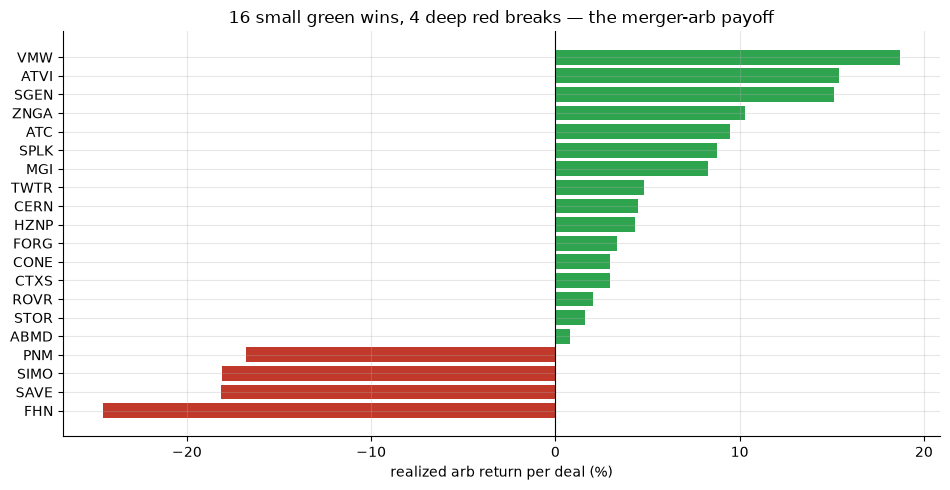

deals that closed: 16  deals that broke: 4


In [2]:
F2 = F.sort_values('ret')
cols = [GREEN if c else RED for c in F2['completed']]
fig, ax = plt.subplots(figsize=(9.6, 5.0))
ax.barh(F2['target'], F2['ret']*100, color=cols)
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('realized arb return per deal (%)')
ax.set_title('16 small green wins, 4 deep red breaks — the merger-arb payoff')
plt.tight_layout(); plt.show()
print('deals that closed:', int(F['completed'].sum()), ' deals that broke:', int((~F['completed']).sum()))

There's the shape. **16 deals closed** and paid a tidy spread; **4 broke** and cost about **-19%** each. The breaks are few, but they're *deep* — and that asymmetry is the entire story.

**Now the punchline: what you *see* vs what you *get*.** The pitch quotes the spread on deals that close. The tape pays the average across *all* deals, breaks included.

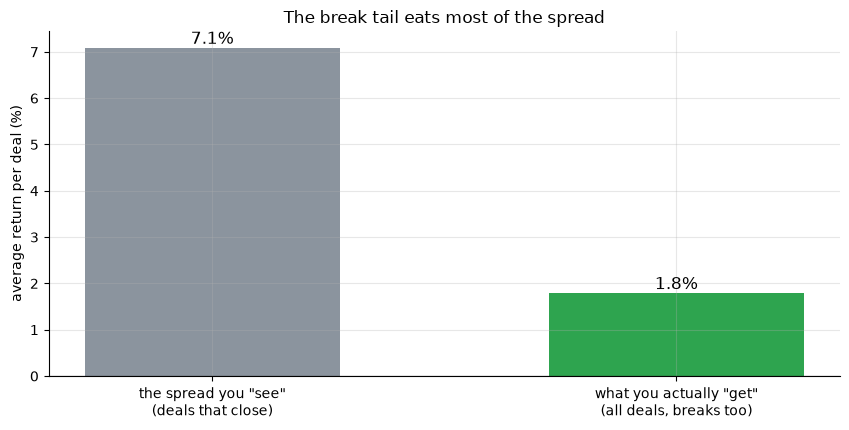

spread if it closes: 7.1%   ->   average across all deals: 1.8%


In [3]:
comp = F[F['completed']]
see = comp['spread'].mean()*100          # 'free lunch' number: spread if it closes
get = st.summarize(F)['mean']*100         # honest mean across ALL deals
fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars = ax.bar(['the spread you \"see\"\n(deals that close)', 'what you actually \"get\"\n(all deals, breaks too)'],
              [see, get], color=[GREY, GREEN], width=.55)
for b,v in zip(bars,[see,get]): ax.annotate(f'{v:.1f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom',fontsize=12)
ax.set_ylabel('average return per deal (%)'); ax.axhline(0,c='k',lw=.8)
ax.set_title('The break tail eats most of the spread')
plt.tight_layout(); plt.show()
print(f'spread if it closes: {see:.1f}%   ->   average across all deals: {get:.1f}%')

The headline **+7.1%** coupon shrinks to **+1.8%** once the four breaks are counted. Most of the apparent free lunch was simply *not pricing the disaster*.

**Is even that +1.8% real?** With only 20 deals and a few huge losers, the average is shaky. Here's the honest test: resample the deal book thousands of times (bootstrap) and see how often the average comes out **zero or negative.**

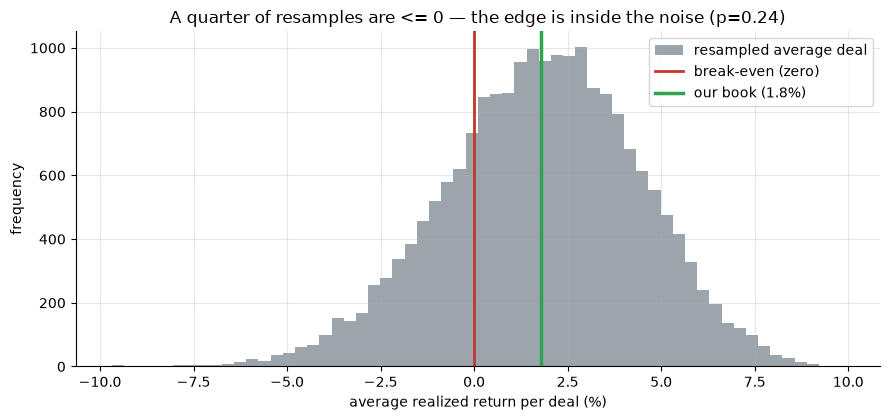

P[average deal <= 0] = 0.24  -> about 1 in 4. Not distinguishable from a fair bet.


In [4]:
r = st.arb_returns(F)
rng = np.random.default_rng(366)
boot = np.array([r[rng.integers(0,len(r),len(r))].mean() for _ in range(20000)])
p0 = (boot <= 0).mean()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(boot*100, bins=60, color=GREY, alpha=.85, label='resampled average deal')
ax.axvline(0, c=RED, lw=2, label='break-even (zero)')
ax.axvline(r.mean()*100, c=GREEN, lw=2.5, label=f'our book ({r.mean()*100:.1f}%)')
ax.set_xlabel('average realized return per deal (%)'); ax.set_ylabel('frequency')
ax.set_title(f'A quarter of resamples are <= 0 — the edge is inside the noise (p={p0:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'P[average deal <= 0] = {p0:.2f}  -> about 1 in 4. Not distinguishable from a fair bet.')

The green line (our book) sits well inside the cloud, and about **24%** of resamples land at zero or below. In plain terms: **the average deal's profit can't be told apart from a fair bet** — exactly what you'd expect if the spread is just the fair price of the break insurance.

## 5 · The verdict

- **Signal — Weak.** The spread is real and you win **80%** of the time — but the average deal (**+1.8%**) is statistically indistinguishable from zero, and the headline spread was gross of a break tail that eats most of it. Real as lore, weak as edge.
- **Tradability — Fragile.** Costs barely matter, but you're **short a deal-break put**: one blocked deal erases a year of spread, and breaks cluster (antitrust waves, financing freezes), so the tail doesn't diversify away.
- **"Free lunch"? — Busted.** The steady coupon is an **insurance premium**. Win small often, lose big rarely — that's selling insurance, not finding free money.

## 6 · Could you actually trade it? — the insurance you're really selling

Forget statistics for a second. Picture the payoff: a row of small steady wins, then occasionally a cliff. That's the profile of an **insurance company** — and it tells you exactly how it fails. Not gradually, but all at once, when many deals break together.

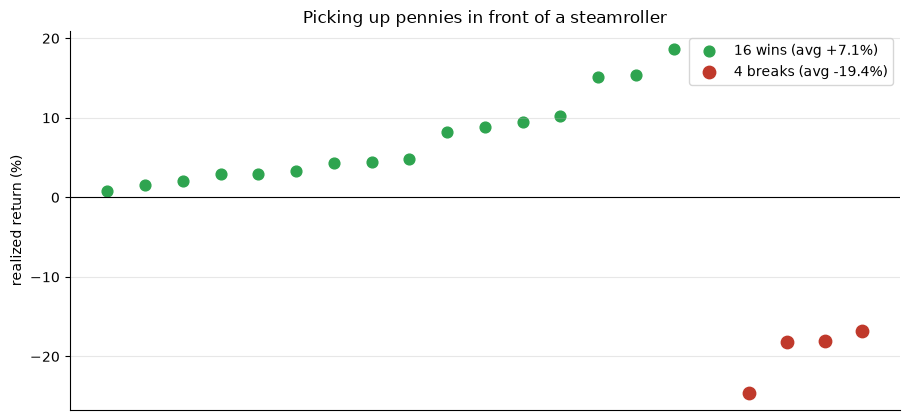

win 7.1% on average, lose -19.4% when it breaks -> short volatility


In [5]:
wins = F[F['completed']]['ret']*100
loss = F[~F['completed']]['ret']*100
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.scatter(np.arange(len(wins)), sorted(wins), c=GREEN, s=60, label=f'{len(wins)} wins (avg +{wins.mean():.1f}%)')
ax.scatter(np.arange(len(loss))+len(wins)+1, sorted(loss), c=RED, s=80, label=f'{len(loss)} breaks (avg {loss.mean():.1f}%)')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('realized return (%)'); ax.set_xticks([])
ax.set_title('Picking up pennies in front of a steamroller')
ax.legend(); plt.tight_layout(); plt.show()
print(f'win {wins.mean():.1f}% on average, lose {loss.mean():.1f}% when it breaks -> short volatility')

Real merger-arb desks survive by holding **dozens** of deals at once to diversify the idiosyncratic break risk. But the dangerous breaks are **correlated** — a hawkish antitrust regime or a frozen financing market can break a whole wave of deals together, and *that* is the loss no amount of diversification removes. Costs aren't the killer here; the **fat left tail** is. You can run this as a *style* (and pros do), but it is not the free coupon the pitch describes.

## 7 · Going further 🚪

- **Price the tail directly.** Estimate each deal's break probability from the spread itself (a wide spread is the market screaming *this one's shaky*), then check whether the spread *over*-pays for that probability. Our finding says: barely, if at all.
- **Diversify and stress it.** Build a 50-deal book and then force a *correlated* break wave (e.g. 2022's antitrust crackdown) — watch the 'market-neutral' coupon take a market-sized hit.
- **The family resemblance.** Covered calls, short-vol carry, selling puts — same payoff shape (win small often, lose big rarely). If you understand one, you understand all of them.

*Think the spread beats fair insurance pricing? Take a bigger, cleaner deal book, count every break, and show the average landing **above zero with a t past 2** — then we'll talk.*